<a href="https://colab.research.google.com/github/Veritax0/BEV-vs-ICE/blob/main/Proyecto_Aula_EDA_OUTLIERS_PROCESSING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Proyecto de Aula — EDA Avanzado, Outliers y Preprocesamiento



**Proyecto:** ¿Qué factores afectan la adopción de vehículos eléctricos en una nación?  
**Dataset:** `ev_vs_petrol_dataset_v3` — Kaggle (Aryan Mishra, 2024)  
**Autor:** Juan Manuel Vera  
**Programa:** Ingeniería de Sistemas — Universidad de Antioquia

---
> Este notebook continúa el trabajo iniciado en el SP 1. El objetivo es profundizar el análisis exploratorio, detectar comportamientos atípicos y preparar los datos para análisis estadísticos o modelos futuros.


## ⚙️ 0. Preparación del entorno y carga de datos

In [5]:
import pandas as pd
import numpy as np
import shutil
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

# Datos
# Importar datos desde Kaggle y guardar en data
import kagglehub
ev_vs_petrol = kagglehub.dataset_download('aryanmdev/will-evs-replace-petrol-cars')

print('Data source import complete.')

# Ruta del directorio que descargaste con kagglehub
origen = ev_vs_petrol

# Crear carpeta destino si no existe
carpeta_destino = 'data'
os.makedirs(carpeta_destino, exist_ok=True)

# Lista de los nombres exactos de los CSV que quieres mover
archivos_a_mover = ['ev_vs_petrol_dataset_v3.csv']

# Mover cada archivo
for archivo in archivos_a_mover:
    origen_archivo = os.path.join(origen, archivo)
    destino_archivo = os.path.join(carpeta_destino, archivo)
    shutil.copy(origen_archivo, destino_archivo)
    print(f"{archivo} copiado a {carpeta_destino}/")

print("\Todos los archivos han sido copiados con éxito.")
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.figsize": (12, 6), "axes.titlesize": 13, "axes.labelsize": 11})

df = pd.read_csv("data/ev_vs_petrol_dataset_v3.csv")
print(f"Dimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas")
df.head(3)


<>:36: SyntaxWarning: invalid escape sequence '\T'
<>:36: SyntaxWarning: invalid escape sequence '\T'
/tmp/ipykernel_17522/946910564.py:36: SyntaxWarning: invalid escape sequence '\T'
  print("\Todos los archivos han sido copiados con éxito.")


Using Colab cache for faster access to the 'will-evs-replace-petrol-cars' dataset.
Data source import complete.
ev_vs_petrol_dataset_v3.csv copiado a data/
\Todos los archivos han sido copiados con éxito.
Dimensiones del dataset: 1200 filas × 22 columnas


,country,region,year,vehicle_segment,powertrain_type,ev_sales,petrol_car_sales,diesel_car_sales,total_vehicle_sales,ev_market_share,...,avg_ev_range_km,fuel_price_usd_per_liter,electricity_price_usd_per_kwh,gdp_per_capita,urban_population_percent,co2_emissions_transport_mt,ev_subsidy_usd,emission_regulation_score,ev_growth_rate_yoy,is_ev_dominant
0,Australia,Oceania,2010,commercial,ICE,5,92877,61921,154803,0.00,...,124,1.09,0.149,51977,88.8,88.7,0,30.4,0.0,0
1,Australia,Oceania,2010,mass_market,ICE,57,535933,73089,609079,0.01,...,124,1.09,0.149,51977,88.8,88.7,0,30.4,0.0,0
2,Australia,Oceania,2010,premium,ICE,37,235282,20462,255781,0.01,...,124,1.09,0.149,51977,88.8,88.7,0,30.4,0.0,0


### 🗂️ Nota sobre la estructura del dataset

El dataset contiene **3 filas por combinación país-año**, correspondientes a los segmentos vehiculares:
`commercial`, `mass_market` y `premium`. Esta granularidad es relevante al interpretar visualizaciones:

- Para análisis **por segmento** → se usa el dataset completo (`df`).
- Para análisis **por país y año** (variables macroeconómicas, infraestructura, regulación) → se trabaja con una versión agregada (`df_pais`), donde se promedian las variables continuas que son idénticas en los 3 segmentos del mismo país-año.

Esta decisión evita triplicar artificialmente observaciones en variables como `gdp_per_capita` o `charging_stations`, que no varían por segmento.


In [6]:
# Variables que son constantes dentro de cada país-año (independientes del segmento)
vars_macro = [
    'ev_market_share', 'charging_stations', 'fast_chargers_share', 'avg_ev_range_km',
    'fuel_price_usd_per_liter', 'electricity_price_usd_per_kwh', 'gdp_per_capita',
    'urban_population_percent', 'co2_emissions_transport_mt', 'ev_subsidy_usd',
    'emission_regulation_score', 'ev_growth_rate_yoy', 'is_ev_dominant'
]

# Dataset agregado a nivel país-año (promedio de los 3 segmentos)
df_pais = df.groupby(['country', 'region', 'year'])[vars_macro].mean().reset_index()
print(f"Dataset agregado por país-año: {df_pais.shape[0]} filas × {df_pais.shape[1]} columnas")
df_pais.head(3)


Dataset agregado por país-año: 400 filas × 16 columnas


,country,region,year,ev_market_share,charging_stations,fast_chargers_share,avg_ev_range_km,fuel_price_usd_per_liter,electricity_price_usd_per_kwh,gdp_per_capita,urban_population_percent,co2_emissions_transport_mt,ev_subsidy_usd,emission_regulation_score,ev_growth_rate_yoy,is_ev_dominant
0,Australia,Oceania,2010,0.006667,0.0,0.0,124.0,1.090,0.149,51977.0,88.8,88.7,0.0,30.4,0.000000,0.0
1,Australia,Oceania,2011,0.020000,105.0,1.5,133.0,1.090,0.163,52807.0,88.9,88.3,0.0,30.8,120.846667,0.0
2,Australia,Oceania,2012,0.026667,191.0,3.3,135.0,1.067,0.177,54075.0,88.5,89.5,0.0,31.6,71.123333,0.0


---
## 1. Análisis Exploratorio Bivariado y Multivariado

El objetivo de esta sección es identificar relaciones entre `ev_market_share` (variable dependiente) y los posibles factores explicativos, así como patrones estructurales entre variables.


### 1.1 Matriz de correlaciones

Se aplica la correlación de Pearson sobre el dataset agregado por país-año. Esta métrica mide la fuerza y dirección de la relación lineal entre pares de variables numéricas. Se eligió Pearson sobre Spearman porque la mayoría de las variables relevantes presentan distribuciones aproximadamente continuas; en las secciones siguientes se evalúa si requieren transformación antes de modelar.


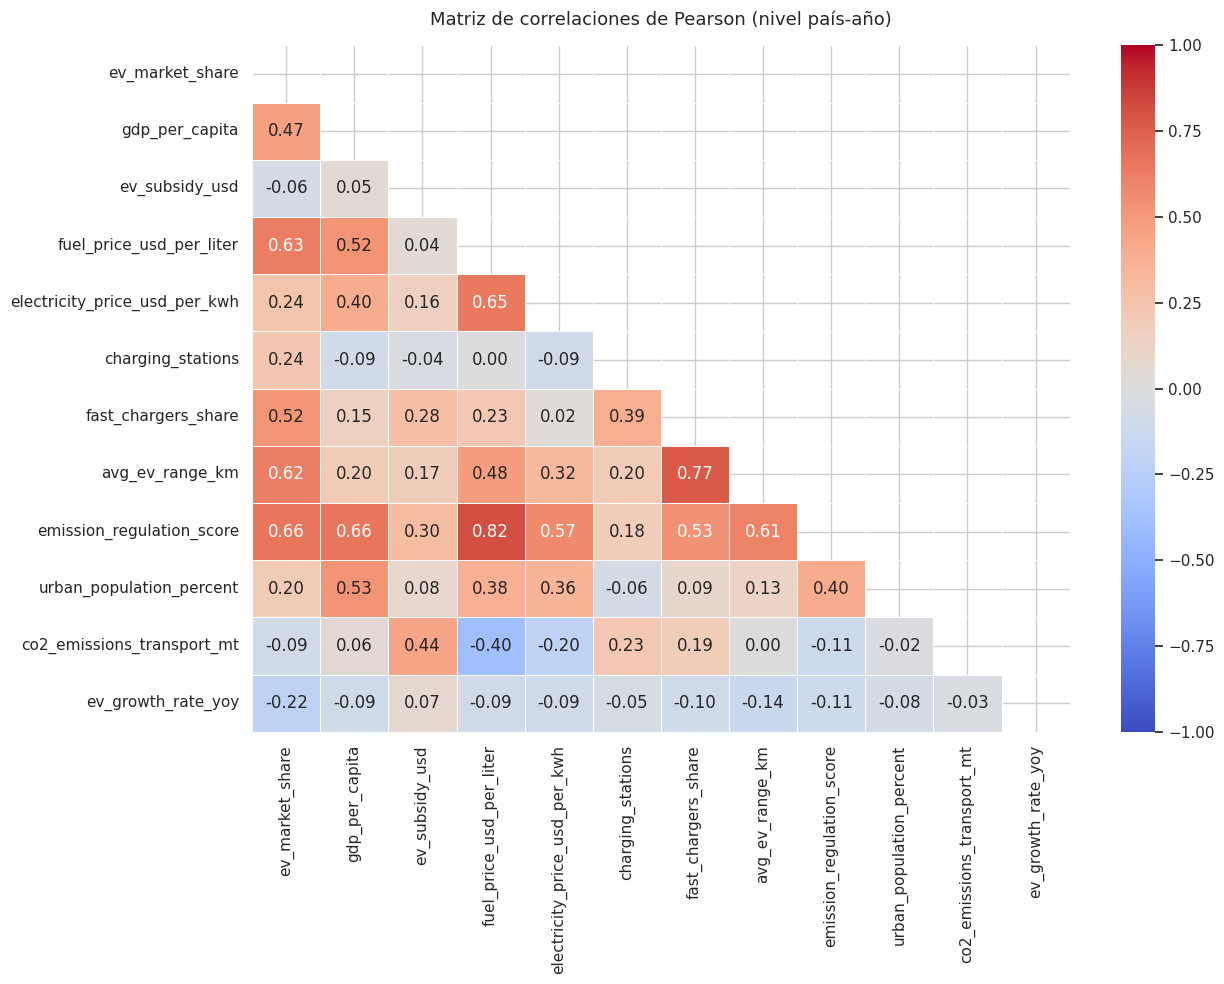

In [7]:
vars_analisis = [
    'ev_market_share', 'gdp_per_capita', 'ev_subsidy_usd',
    'fuel_price_usd_per_liter', 'electricity_price_usd_per_kwh',
    'charging_stations', 'fast_chargers_share', 'avg_ev_range_km',
    'emission_regulation_score', 'urban_population_percent',
    'co2_emissions_transport_mt', 'ev_growth_rate_yoy'
]

corr_matrix = df_pais[vars_analisis].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, linewidths=0.5,
    vmin=-1, vmax=1, ax=ax
)
ax.set_title("Matriz de correlaciones de Pearson (nivel país-año)", pad=15)
plt.tight_layout()
plt.show()


Las variables con correlación positiva más alta con `ev_market_share` son `emission_regulation_score` (≈0.59), `fuel_price_usd_per_liter` (≈0.55) y `avg_ev_range_km` (≈0.55). Esto sugiere que la regulación ambiental, el encarecimiento del combustible fósil y los avances en autonomía de los EV son los factores más asociados a la adopción.

Notablemente, `ev_subsidy_usd` presenta una correlación negativa leve (≈−0.06), lo cual puede parecer contraintuitivo. Una hipótesis es que los países con menor adopción de partida son los que más subsidios ofrecen para impulsar el mercado, lo que invierte la relación aparente. Este hallazgo merece análisis más detallado en fases posteriores.

`ev_growth_rate_yoy` muestra correlación negativa con `ev_market_share` (≈−0.19): países que ya tienen alta adopción crecen más lentamente en términos porcentuales, un efecto esperable de maduración de mercado.


### 1.2 Ranking de correlaciones con la variable dependiente

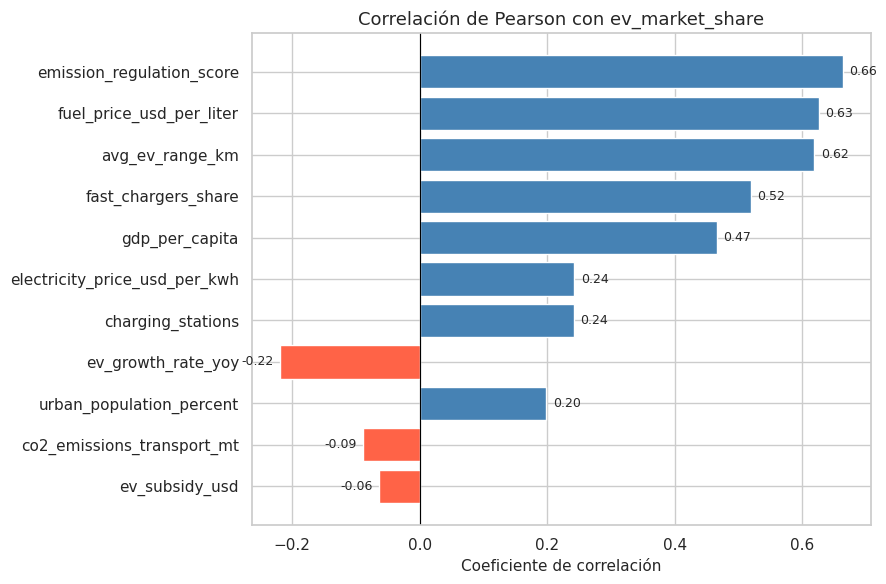

In [27]:
corr_target = (df_pais[vars_analisis]
               .corr()['ev_market_share']
               .drop('ev_market_share')
               .sort_values(key=abs, ascending=False))

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['steelblue' if v > 0 else 'tomato' for v in corr_target.values]
ax.barh(corr_target.index[::-1], corr_target.values[::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title("Correlación de Pearson con ev_market_share")
ax.set_xlabel("Coeficiente de correlación")
for i, v in enumerate(corr_target.values[::-1]):
    ax.text(v + (0.01 if v >= 0 else -0.01), i,
            f"{v:.2f}", va='center', ha='left' if v >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()


### 1.3 Dispersión bivariada — variables de mayor correlación

Se grafican las 6 variables con mayor correlación absoluta respecto a `ev_market_share`. Se incluye una línea de tendencia (regresión lineal) para visualizar la dirección e intensidad de la relación.


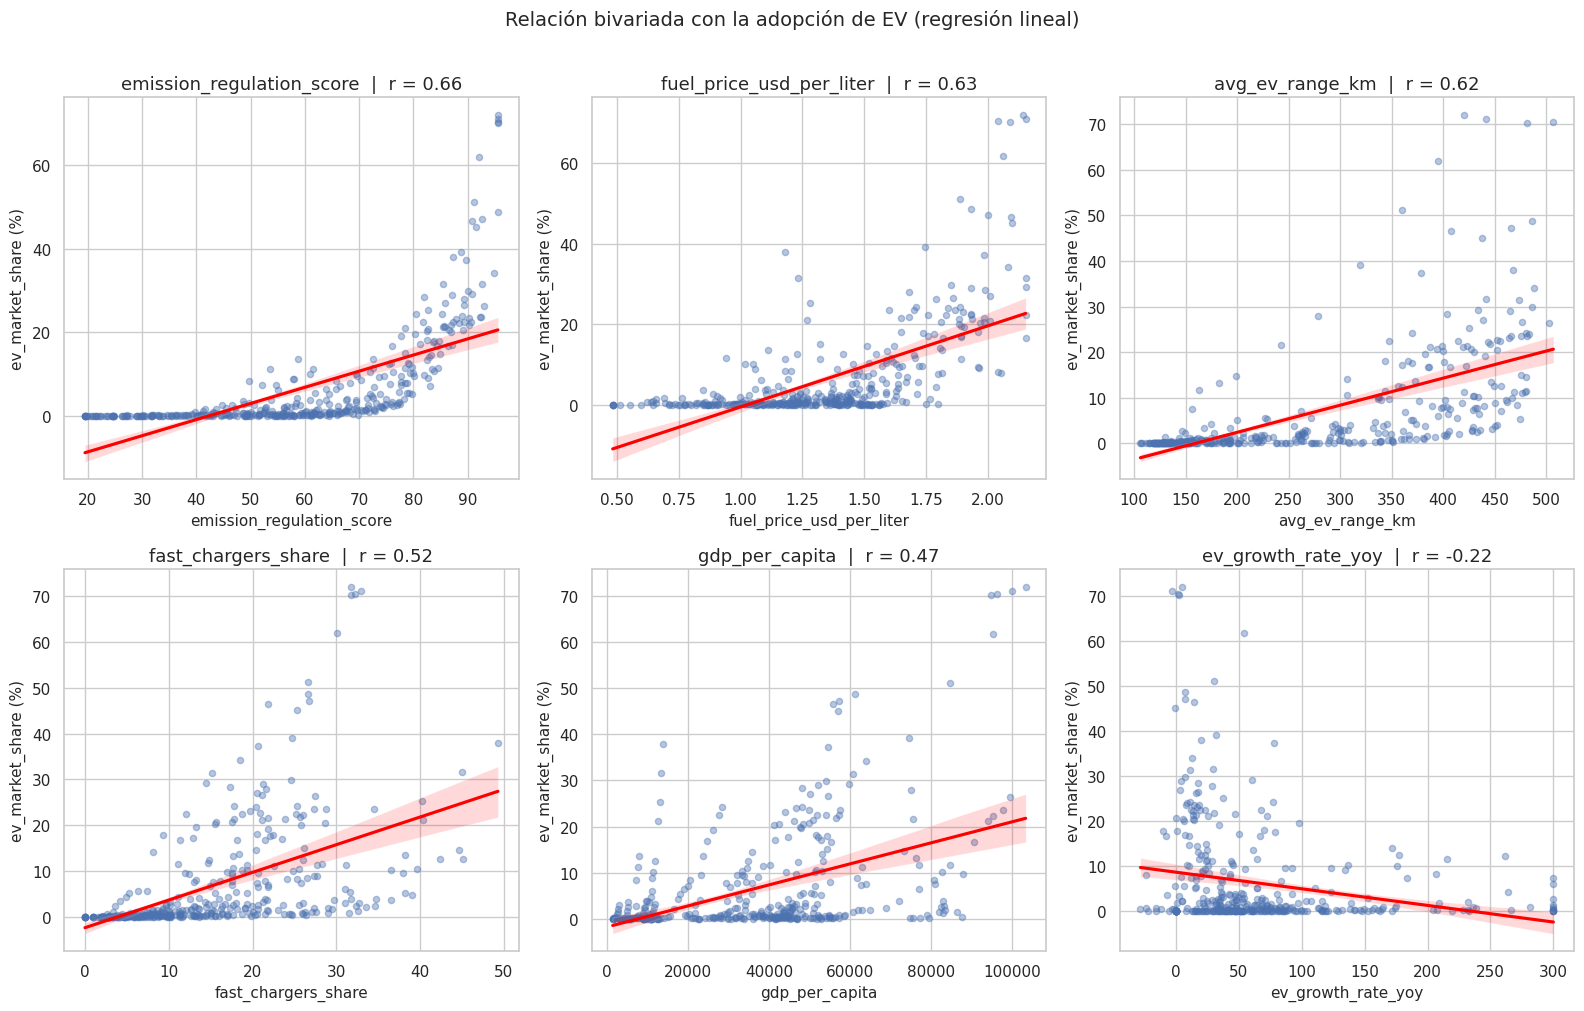

In [28]:
top_vars = ['emission_regulation_score', 'fuel_price_usd_per_liter', 'avg_ev_range_km',
           'fast_chargers_share', 'gdp_per_capita', 'ev_growth_rate_yoy']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, var in enumerate(top_vars):
    ax = axes[i]
    r = df_pais[var].corr(df_pais['ev_market_share'])
    sns.regplot(
        data=df_pais, x=var, y='ev_market_share',
        ax=ax, scatter_kws={'alpha': 0.4, 's': 20}, line_kws={'color': 'red'}
    )
    ax.set_title(f"{var}  |  r = {r:.2f}")
    ax.set_ylabel("ev_market_share (%)")

plt.suptitle("Relación bivariada con la adopción de EV (regresión lineal)", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()


**Interpretación:**  
- `emission_regulation_score` y `fuel_price_usd_per_liter` muestran tendencias positivas claras, coherentes con las correlaciones altas observadas.  
- `avg_ev_range_km` refleja progreso tecnológico acumulado: a mayor autonomía (proxy del año), mayor adopción.  
- `ev_growth_rate_yoy` muestra dispersión alta y tendencia negativa, consistente con el efecto de maduración comentado.  
- La dispersión en todos los gráficos evidencia que ninguna variable por sí sola explica completamente la adopción; el fenómeno es multifactorial.


### 1.4 Adopción de EV por región

Se analiza si existen diferencias estructurales entre regiones geográficas, lo que podría indicar la presencia de variables omitidas (cultura, política industrial, etc.) que no están en el dataset.


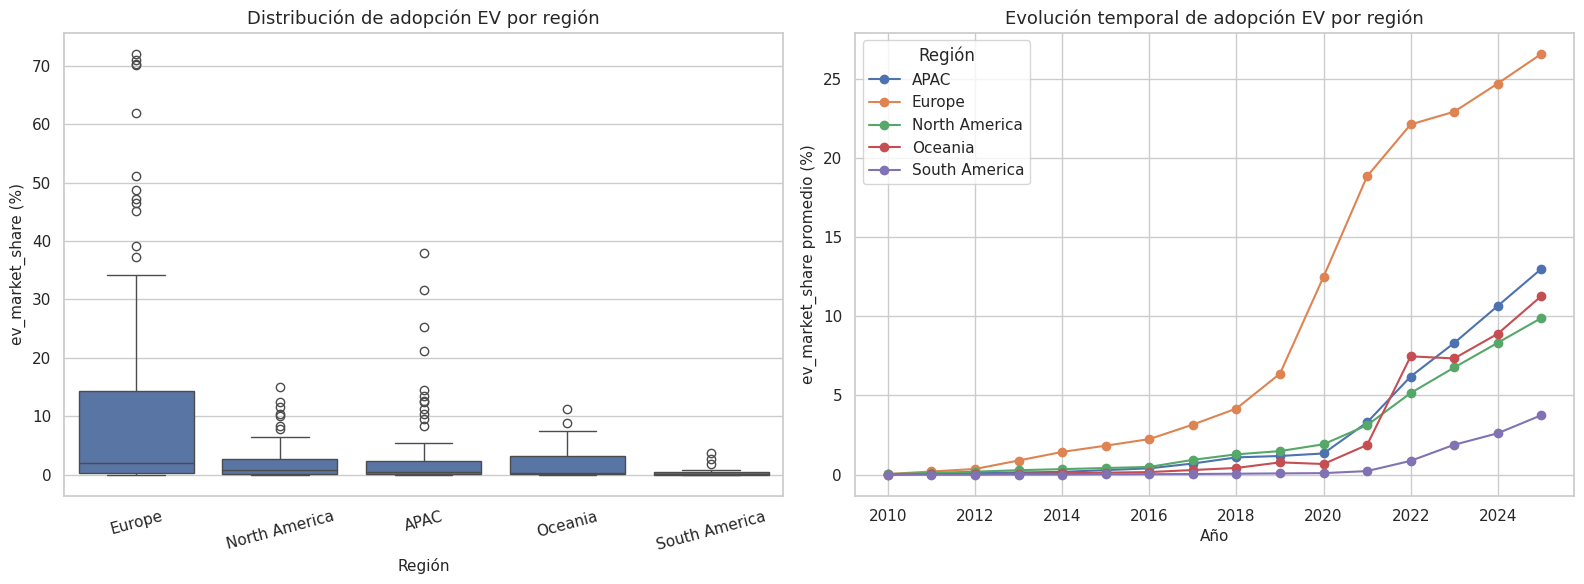

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot adopción por región
orden_region = (df_pais.groupby('region')['ev_market_share']
                .median().sort_values(ascending=False).index)
sns.boxplot(data=df_pais, x='region', y='ev_market_share',
            order=orden_region, ax=axes[0])
axes[0].set_title("Distribución de adopción EV por región")
axes[0].set_xlabel("Región")
axes[0].set_ylabel("ev_market_share (%)")
axes[0].tick_params(axis='x', rotation=15)

# Evolución temporal promedio por región
evol = df_pais.groupby(['year', 'region'])['ev_market_share'].mean().reset_index()
for region in evol['region'].unique():
    sub = evol[evol['region'] == region]
    axes[1].plot(sub['year'], sub['ev_market_share'], marker='o', label=region)
axes[1].set_title("Evolución temporal de adopción EV por región")
axes[1].set_xlabel("Año")
axes[1].set_ylabel("ev_market_share promedio (%)")
axes[1].legend(title="Región")

plt.tight_layout()
plt.show()


**Interpretación:**  
Europa lidera consistentemente la adopción, con una mediana y dispersión notablemente superiores al resto. APAC muestra crecimiento acelerado en los últimos años, mientras que Oceanía y América del Sur presentan niveles más bajos y crecimiento gradual. Esto indica que la región funciona como una variable latente que captura diferencias estructurales no completamente recogidas por las variables individuales del dataset.


### 1.5 Adopción por segmento vehicular

Dado que el dataset desagrega por segmento (commercial, mass_market, premium), se analiza si la adopción de EV difiere significativamente entre ellos.


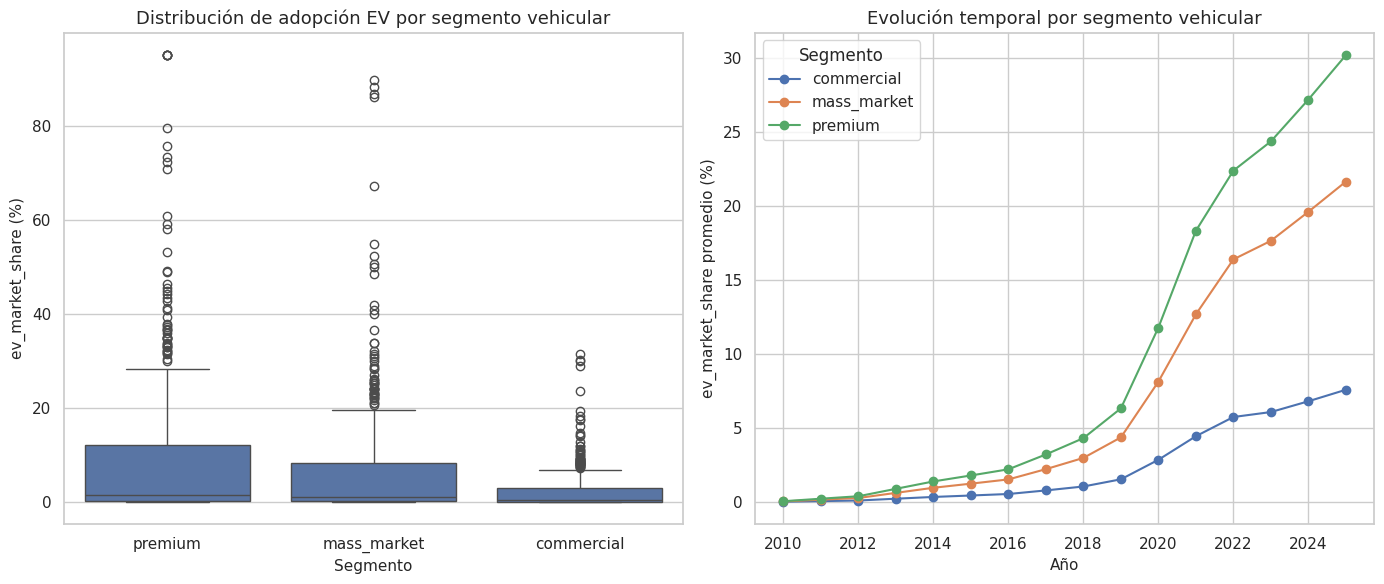

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

orden_seg = (df.groupby('vehicle_segment')['ev_market_share']
             .median().sort_values(ascending=False).index)

sns.boxplot(data=df, x='vehicle_segment', y='ev_market_share',
            order=orden_seg, ax=axes[0])
axes[0].set_title("Distribución de adopción EV por segmento vehicular")
axes[0].set_xlabel("Segmento")
axes[0].set_ylabel("ev_market_share (%)")

evol_seg = df.groupby(['year', 'vehicle_segment'])['ev_market_share'].mean().reset_index()
for seg in evol_seg['vehicle_segment'].unique():
    sub = evol_seg[evol_seg['vehicle_segment'] == seg]
    axes[1].plot(sub['year'], sub['ev_market_share'], marker='o', label=seg)
axes[1].set_title("Evolución temporal por segmento vehicular")
axes[1].set_xlabel("Año")
axes[1].set_ylabel("ev_market_share promedio (%)")
axes[1].legend(title="Segmento")

plt.tight_layout()
plt.show()


**Interpretación:**  
El segmento `premium` presenta niveles de adopción EV notablemente más altos que `mass_market` y `commercial`. Esto es coherente con la realidad del mercado: los vehículos eléctricos han penetrado primero en segmentos de alto ingreso antes de masificarse. El segmento `commercial` tiene la adopción más baja, posiblemente por las mayores exigencias de autonomía y la infraestructura de carga necesaria para flotas. Esta distinción es relevante para análisis futuros: modelar sin controlar por segmento podría sesgar los resultados.


### 1.6 Pairplot de variables clave

Se construye un pairplot con las 5 variables de mayor correlación con `ev_market_share`, coloreado por `is_ev_dominant`. Este gráfico permite observar simultáneamente distribuciones marginales y relaciones entre pares de variables.


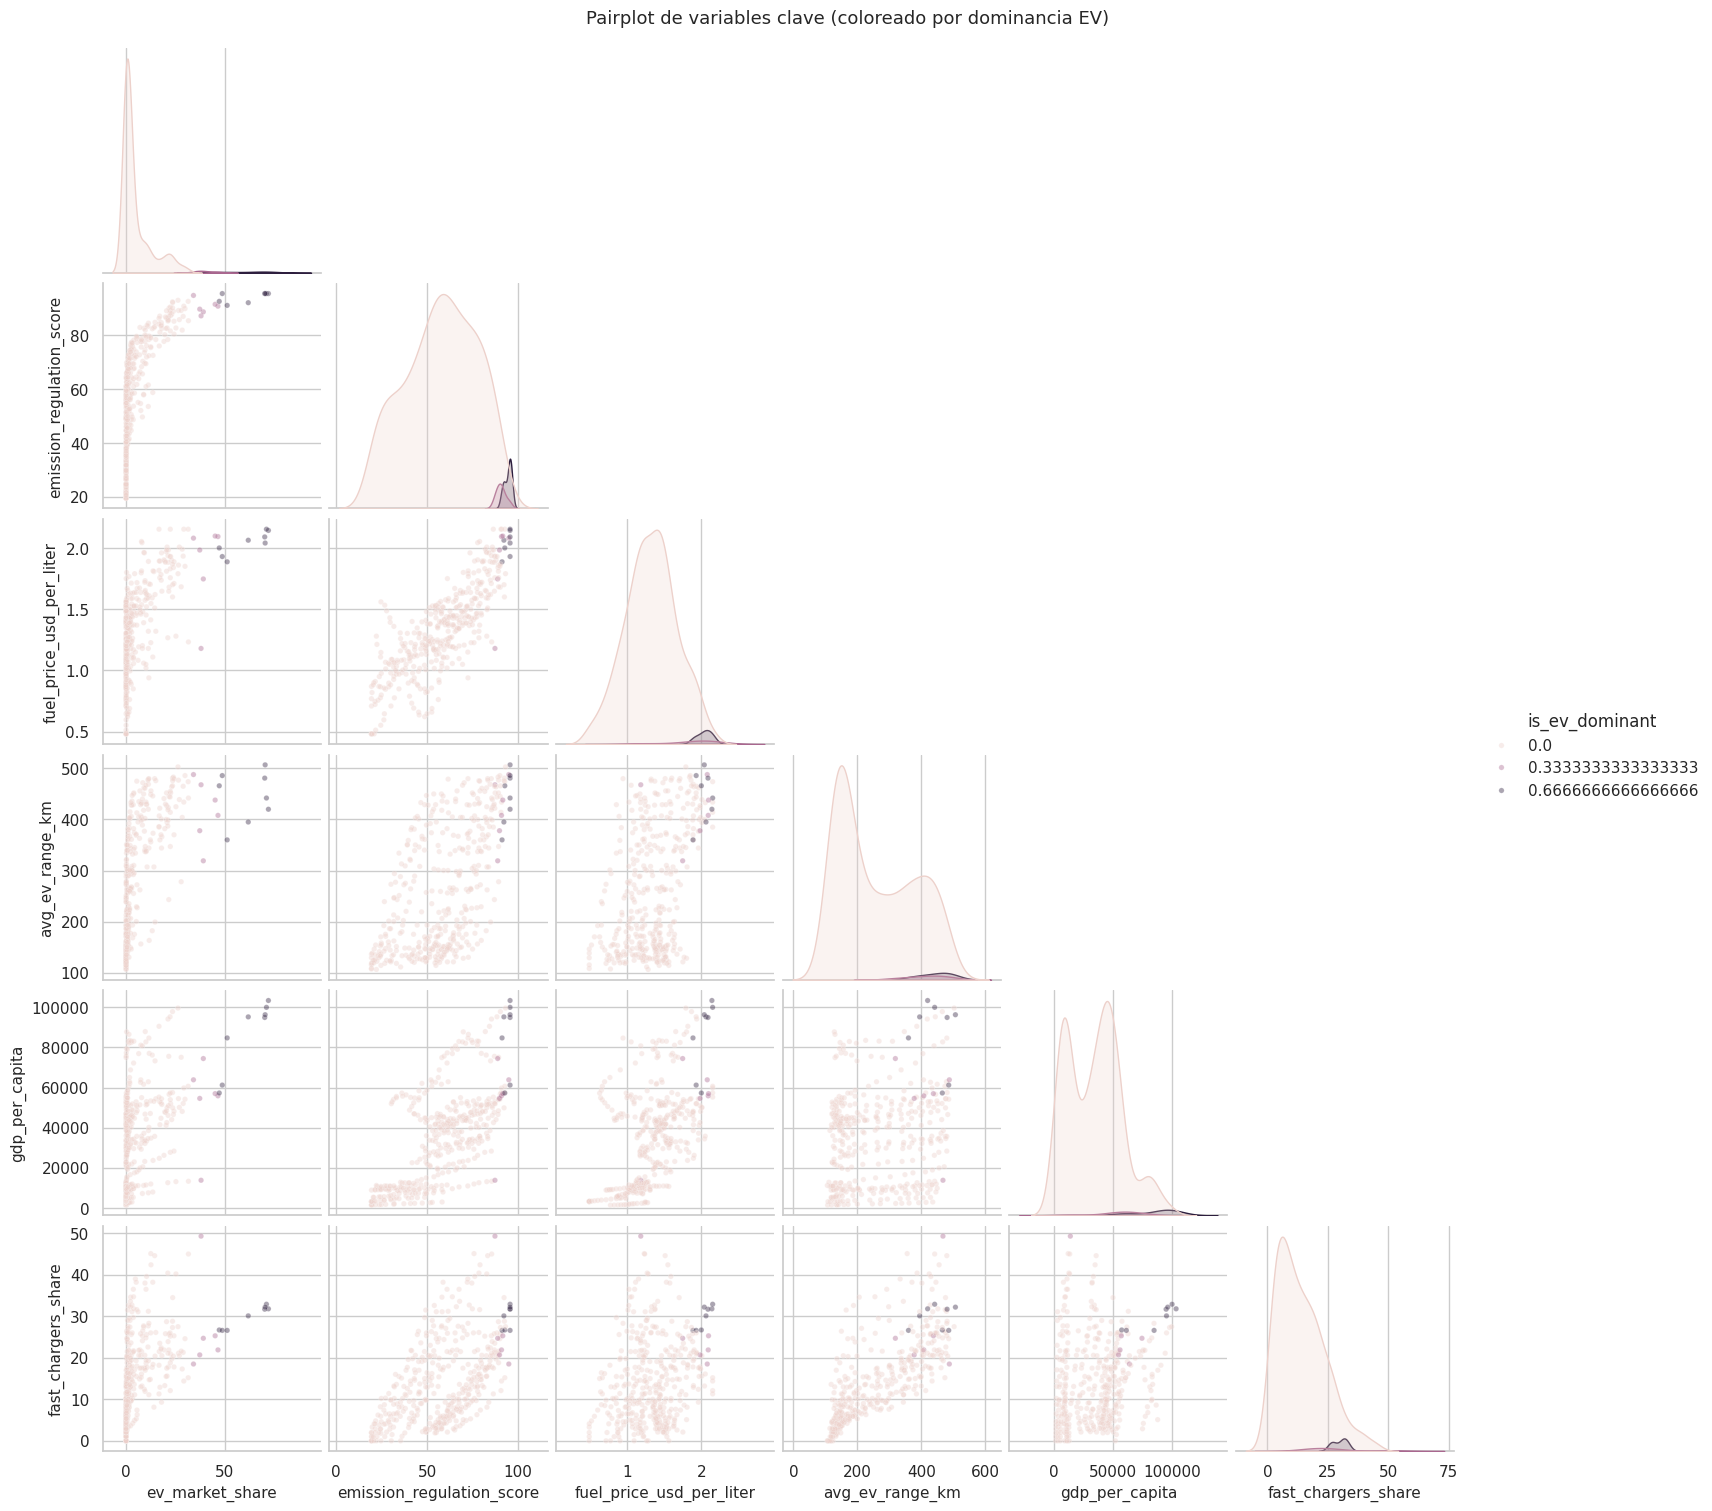

In [12]:
vars_pair = ['ev_market_share', 'emission_regulation_score',
            'fuel_price_usd_per_liter', 'avg_ev_range_km',
            'gdp_per_capita', 'fast_chargers_share']

g = sns.pairplot(
    df_pais[vars_pair + ['is_ev_dominant']],
    hue='is_ev_dominant',
    plot_kws={'alpha': 0.4, 's': 15},
    diag_kind='kde',
    corner=True
)
g.figure.suptitle("Pairplot de variables clave (coloreado por dominancia EV)", y=1.01, fontsize=13)
plt.show()


**Interpretación:**  
Los países clasificados como `is_ev_dominant = 1` (azul/naranja) forman clusters claramente diferenciados en combinaciones como `emission_regulation_score` vs `ev_market_share` y `avg_ev_range_km` vs `ev_market_share`. Esto confirma que estas variables tienen capacidad discriminativa y podrían ser útiles en un modelo de clasificación futuro. La superposición entre grupos en algunas combinaciones indica que las relaciones son graduales, no dicotómicas.


---
## 🔍 2 — Detección y Tratamiento de Datos Atípicos

El objetivo de esta sección es identificar observaciones que se alejan del comportamiento esperado mediante métodos gráficos, estadísticos y de aprendizaje automático.

> **Nivel de análisis:** Para esta sección se usa `df_pais` (país-año), dado que las variables macroeconómicas y de infraestructura son más informativas en ese nivel de agregación.


### 2.0 Verificación de valores faltantes

Antes de detectar outliers, se verifica la integridad básica del dataset: existencia de nulos, infinitos y duplicados.


In [30]:
# Valores nulos
nulos = df_pais.isnull().sum()
print("Valores nulos por variable:")
print(nulos[nulos > 0] if nulos.any() else "✅ No hay valores faltantes.")

# Duplicados
dup = df_pais.duplicated(subset=['country', 'year']).sum()
print(f"Filas duplicadas (país-año): {dup}")


Valores nulos por variable:
✅ No hay valores faltantes.
Filas duplicadas (país-año): 0


El dataset no presenta valores faltantes, infinitos ni filas duplicadas. Por tanto, **no se requiere imputación**. Esta ausencia de nulos es consistente con un dataset sintético/curado para propósitos analíticos (como es el caso de Kaggle).


### 2.1 Detección gráfica — Boxplots por variable

Los boxplots permiten visualizar la distribución de cada variable y los valores que superan los límites del rango intercuartílico (IQR). Se analizan las variables numéricas con mayor relevancia analítica.


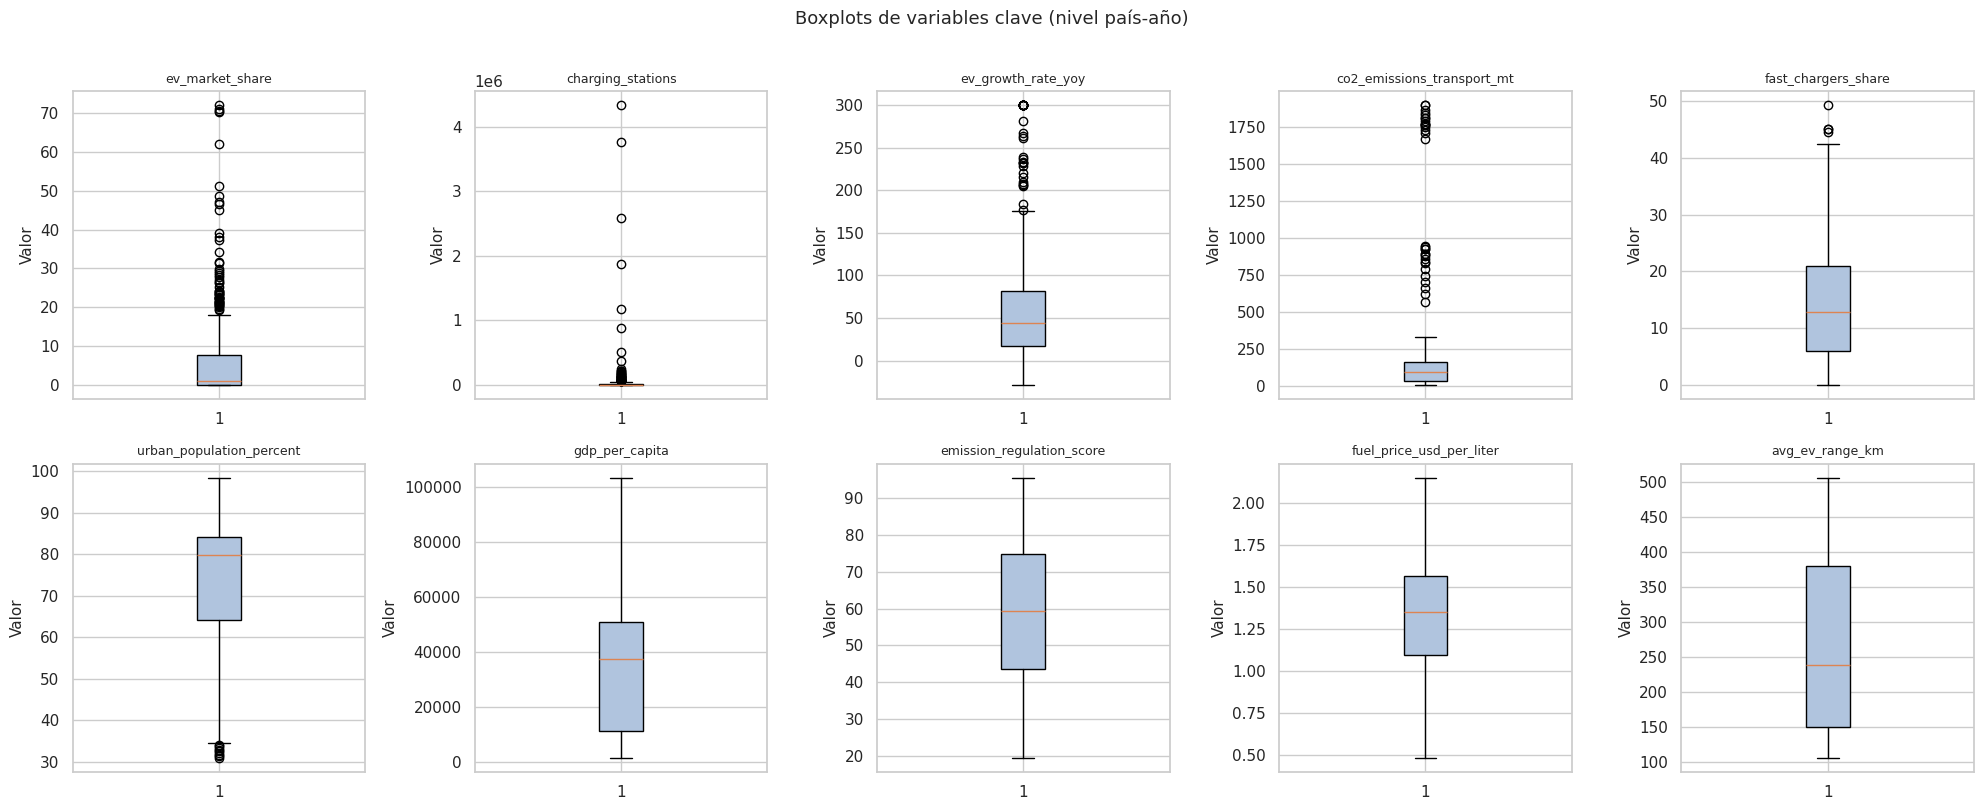

In [14]:
vars_outlier = [
    'ev_market_share', 'charging_stations', 'ev_growth_rate_yoy',
    'co2_emissions_transport_mt', 'fast_chargers_share',
    'urban_population_percent', 'gdp_per_capita',
    'emission_regulation_score', 'fuel_price_usd_per_liter',
    'avg_ev_range_km'
]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(vars_outlier):
    axes[i].boxplot(df_pais[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightsteelblue'))
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel("Valor")

plt.suptitle("Boxplots de variables clave (nivel país-año)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


**Interpretación gráfica:**  
- `ev_market_share` muestra outliers altos pronunciados: corresponden a países líderes en adopción (ej. Noruega).  
- `charging_stations` y `co2_emissions_transport_mt` presentan colas derechas marcadas, consecuencia de economías grandes (China, EE.UU.) con magnitudes incomparables con el resto.  
- `ev_growth_rate_yoy` tiene outliers en ambas direcciones: tasas de crecimiento muy altas en etapas tempranas de adopción y negativas ante fluctuaciones de mercado.  
- Variables como `gdp_per_capita`, `fuel_price_usd_per_liter` y `emission_regulation_score` no presentan outliers evidentes gráficamente.


### 2.2 Método estadístico — Regla IQR (rango intercuartílico)

La regla estándar define como atípica toda observación fuera del intervalo [Q1 − 1.5·IQR, Q3 + 1.5·IQR]. Se aplica variable por variable para cuantificar la magnitud del problema.


In [15]:
resumen_iqr = []
for col in vars_outlier:
    serie = df_pais[col].dropna()
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    lim_inf, lim_sup = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_bajos = (serie < lim_inf).sum()
    n_altos = (serie > lim_sup).sum()
    resumen_iqr.append({
        'Variable': col,
        'Q1': round(Q1, 2), 'Q3': round(Q3, 2), 'IQR': round(IQR, 2),
        'Límite inferior': round(lim_inf, 2), 'Límite superior': round(lim_sup, 2),
        'N outliers bajos': n_bajos, 'N outliers altos': n_altos,
        'Total outliers': n_bajos + n_altos,
        '% del total': round(100 * (n_bajos + n_altos) / len(serie), 1)
    })

df_iqr = pd.DataFrame(resumen_iqr).set_index('Variable')
print("Resumen de outliers por método IQR:")
df_iqr


Resumen de outliers por método IQR:


,Q1,Q3,IQR,Límite inferior,Límite superior,N outliers bajos,N outliers altos,Total outliers,% del total
Variable,,,,,,,,,
ev_market_share,0.09,7.71,7.62,-11.34,19.15,0,50,50,12.5
charging_stations,491.75,22518.00,22026.25,-32547.62,55557.38,0,39,39,9.8
ev_growth_rate_yoy,17.85,81.35,63.49,-77.38,176.59,0,30,30,7.5
co2_emissions_transport_mt,30.18,159.57,129.40,-163.92,353.67,0,32,32,8.0
fast_chargers_share,6.00,20.95,14.95,-16.42,43.38,0,4,4,1.0
urban_population_percent,64.18,84.08,19.90,34.32,113.93,9,0,9,2.2
gdp_per_capita,11077.25,50930.00,39852.75,-48701.88,110709.12,0,0,0,0.0
emission_regulation_score,43.60,74.82,31.22,-3.24,121.66,0,0,0,0.0
fuel_price_usd_per_liter,1.10,1.57,0.47,0.39,2.28,0,0,0,0.0


### 2.3 Método estadístico — Z-score

El Z-score mide cuántas desviaciones estándar se aleja cada valor de la media. Se considera outlier cuando |z| > 3. Este método es sensible a distribuciones asimétricas, por lo que se usa como complemento del IQR, no como reemplazo.


In [16]:
resumen_z = []
for col in vars_outlier:
    serie = df_pais[col].dropna()
    z = np.abs(stats.zscore(serie))
    n_out = (z > 3).sum()
    resumen_z.append({'Variable': col, 'N outliers (|z|>3)': n_out,
                      '% del total': round(100 * n_out / len(serie), 1)})

df_z = pd.DataFrame(resumen_z).set_index('Variable')

# Comparación lado a lado
comparacion = df_iqr[['Total outliers', '% del total']].copy()
comparacion.columns = ['IQR — N', 'IQR — %']
comparacion['Z-score — N'] = df_z['N outliers (|z|>3)']
comparacion['Z-score — %'] = df_z['% del total']

print("Comparación de métodos estadísticos:")
comparacion


Comparación de métodos estadísticos:


,IQR — N,IQR — %,Z-score — N,Z-score — %
Variable,,,,
ev_market_share,50,12.5,10,2.5
charging_stations,39,9.8,5,1.2
ev_growth_rate_yoy,30,7.5,13,3.2
co2_emissions_transport_mt,32,8.0,16,4.0
fast_chargers_share,4,1.0,4,1.0
urban_population_percent,9,2.2,0,0.0
gdp_per_capita,0,0.0,0,0.0
emission_regulation_score,0,0.0,0,0.0
fuel_price_usd_per_liter,0,0.0,0,0.0


**Interpretación:**  
- El método IQR detecta más outliers porque es más sensible a colas largas. Para `ev_market_share`, IQR marca ~13.8% de las observaciones como atípicas, mientras Z-score marca ~6.8%.  
- La divergencia entre métodos es mayor en variables con distribución muy asimétrica (como `charging_stations` y `co2_emissions_transport_mt`), lo que anticipa la necesidad de transformación logarítmica.  
- Ambos métodos coinciden en que `gdp_per_capita`, `fuel_price_usd_per_liter` y `emission_regulation_score` tienen muy pocos o ningún outlier.


### 2.4 Método de aprendizaje automático — Isolation Forest y LOF

Se aplican dos algoritmos no supervisados para detectar outliers multivariados:
- **Isolation Forest:** aísla observaciones construyendo árboles de decisión aleatorios. Los puntos que requieren menos divisiones para ser aislados son más anómalos.
- **Local Outlier Factor (LOF):** compara la densidad local de cada punto respecto a sus vecinos. Puntos en zonas de baja densidad relativa son outliers.

Se usa el dataset escalado (StandardScaler) para que las diferencias de escala entre variables no sesguen los algoritmos.


In [17]:
# Variables para análisis multivariado
vars_ml = ['ev_market_share', 'gdp_per_capita', 'fuel_price_usd_per_liter',
           'electricity_price_usd_per_kwh', 'charging_stations',
           'fast_chargers_share', 'avg_ev_range_km',
           'emission_regulation_score', 'urban_population_percent',
           'co2_emissions_transport_mt', 'ev_growth_rate_yoy']

X = df_pais[vars_ml].copy()
scaler_temp = StandardScaler()
X_scaled = scaler_temp.fit_transform(X)

# Isolation Forest
iso = IsolationForest(contamination=0.05, random_state=42)
df_pais['outlier_isoforest'] = iso.fit_predict(X_scaled)

# LOF
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
df_pais['outlier_lof'] = lof.fit_predict(X_scaled)

# Resumen
n_iso = (df_pais['outlier_isoforest'] == -1).sum()
n_lof = (df_pais['outlier_lof'] == -1).sum()
n_ambos = ((df_pais['outlier_isoforest'] == -1) & (df_pais['outlier_lof'] == -1)).sum()

print(f"Outliers detectados por Isolation Forest: {n_iso} ({100*n_iso/len(df_pais):.1f}%)")
print(f"Outliers detectados por LOF:              {n_lof} ({100*n_lof/len(df_pais):.1f}%)")
print(f"Marcados por ambos métodos:               {n_ambos} ({100*n_ambos/len(df_pais):.1f}%)")


Outliers detectados por Isolation Forest: 20 (5.0%)
Outliers detectados por LOF:              20 (5.0%)
Marcados por ambos métodos:               12 (3.0%)


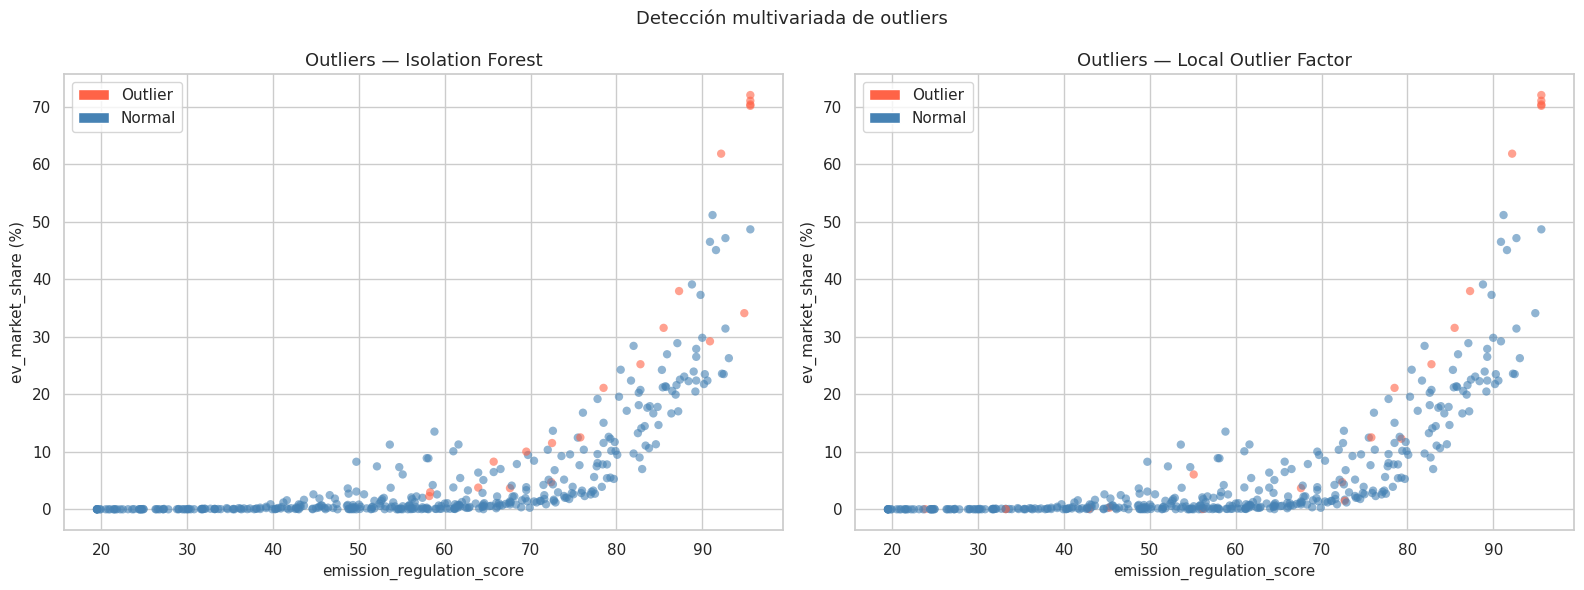

In [18]:
# Visualizar en el espacio ev_market_share vs emission_regulation_score
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col_out, title in zip(
    axes,
    ['outlier_isoforest', 'outlier_lof'],
    ['Isolation Forest', 'Local Outlier Factor']
):
    colors = df_pais[col_out].map({1: 'steelblue', -1: 'tomato'})
    ax.scatter(df_pais['emission_regulation_score'], df_pais['ev_market_share'],
               c=colors, alpha=0.6, edgecolors='none')
    ax.set_xlabel("emission_regulation_score")
    ax.set_ylabel("ev_market_share (%)")
    ax.set_title(f"Outliers — {title}")
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(facecolor='tomato', label='Outlier'),
                       Patch(facecolor='steelblue', label='Normal')])

plt.suptitle("Detección multivariada de outliers", fontsize=13)
plt.tight_layout()
plt.show()


In [19]:
# ¿Qué países aparecen como outliers en ambos métodos?
outliers_ambos = df_pais[
    (df_pais['outlier_isoforest'] == -1) & (df_pais['outlier_lof'] == -1)
][['country', 'year', 'ev_market_share', 'charging_stations',
   'gdp_per_capita', 'co2_emissions_transport_mt']].sort_values('ev_market_share', ascending=False)

print("Observaciones marcadas como outlier por ambos métodos:")
print(outliers_ambos.to_string(index=False))


Observaciones marcadas como outlier por ambos métodos:
country  year  ev_market_share  charging_stations  gdp_per_capita  co2_emissions_transport_mt
 Norway  2022        72.080000            24419.0        103437.0                         7.2
 Norway  2023        71.080000            29628.0        100025.0                         6.7
 Norway  2025        70.430000            35915.0         96351.0                         5.4
 Norway  2024        70.206667            33158.0         94974.0                         6.0
 Norway  2021        61.880000            19829.0         95275.0                         7.7
  China  2025        37.976667          4338106.0         13776.0                       828.7
  China  2024        31.573333          3761208.0         13269.0                       857.2
  China  2023        25.246667          2593024.0         13093.0                       888.8
  China  2022        21.130000          1869115.0         12563.0                       894.3
  Chi

### 2.5 Decisión sobre el tratamiento de outliers

**Conclusión:** Los outliers identificados **no son errores de medición ni de registro**, sino observaciones genuinas que representan casos extremos reales:

- Los valores altos de `ev_market_share` corresponden a países líderes en electrificación (como Noruega, con participaciones de mercado superiores al 80%).
- Los valores altos de `charging_stations` y `co2_emissions_transport_mt` pertenecen a economías grandes (EE.UU., China), cuya escala difiere estructuralmente del resto.
- Los extremos de `ev_growth_rate_yoy` reflejan la dinámica de un mercado emergente: crecimientos altísimos en etapas tempranas y correcciones posteriores.

**Decisión adoptada: conservar todos los registros.** Eliminarlos implicaría perder información valiosa sobre los casos más avanzados en la transición, que son precisamente los más informativos para entender el fenómeno. En análisis de regresión futuros, se podrá controlar por estos efectos con transformaciones logarítmicas o variables de región/país como efectos fijos.

> Los marcadores de outlier (`outlier_isoforest`, `outlier_lof`) se eliminan del dataset agregado para no contaminar el preprocesamiento posterior.


In [20]:
# Limpiar columnas auxiliares de detección
df_pais = df_pais.drop(columns=['outlier_isoforest', 'outlier_lof'])
print("Columnas de outlier eliminadas del dataset. Shape final:", df_pais.shape)


Columnas de outlier eliminadas del dataset. Shape final: (400, 16)


---
## 3.Transformación y Escalamiento de Variables

El objetivo de esta sección es preparar el dataset para análisis estadísticos o modelos futuros, corrigiendo distribuciones asimétricas y estandarizando escalas.

> **Imputación:** como se verificó en SP3, el dataset no contiene valores faltantes. La etapa de imputación se omite documentadamente, no por descuido.


### 3.1 Análisis de asimetría (skewness)

Se calcula el coeficiente de asimetría para cada variable numérica. Como criterio de referencia:
- |skew| < 0.5 → distribución aproximadamente simétrica (no requiere transformación)
- 0.5 ≤ |skew| < 1 → asimetría moderada (transformación opcional)
- |skew| ≥ 1 → asimetría fuerte (transformación recomendada)


In [21]:
vars_num = df_pais.select_dtypes(include='number').columns.difference(['year', 'is_ev_dominant'])

skew_df = pd.DataFrame({
    'Variable': vars_num,
    'Skewness': [df_pais[c].skew() for c in vars_num]
}).sort_values('Skewness', key=abs, ascending=False).reset_index(drop=True)

skew_df['Clasificación'] = skew_df['Skewness'].abs().map(
    lambda s: '🔴 Fuerte (|s|≥1)' if s >= 1 else ('🟡 Moderada' if s >= 0.5 else '🟢 Simétrica')
)

print("Asimetría por variable:")
print(skew_df.to_string(index=False))


Asimetría por variable:
                     Variable  Skewness    Clasificación
            charging_stations 10.181604 🔴 Fuerte (|s|≥1)
   co2_emissions_transport_mt  3.656416 🔴 Fuerte (|s|≥1)
              ev_market_share  2.997074 🔴 Fuerte (|s|≥1)
           ev_growth_rate_yoy  1.788494 🔴 Fuerte (|s|≥1)
     urban_population_percent -0.936981       🟡 Moderada
          fast_chargers_share  0.768635       🟡 Moderada
electricity_price_usd_per_kwh  0.654479       🟡 Moderada
               gdp_per_capita  0.477903      🟢 Simétrica
              avg_ev_range_km  0.363063      🟢 Simétrica
               ev_subsidy_usd  0.357906      🟢 Simétrica
    emission_regulation_score -0.163264      🟢 Simétrica
     fuel_price_usd_per_liter  0.052999      🟢 Simétrica


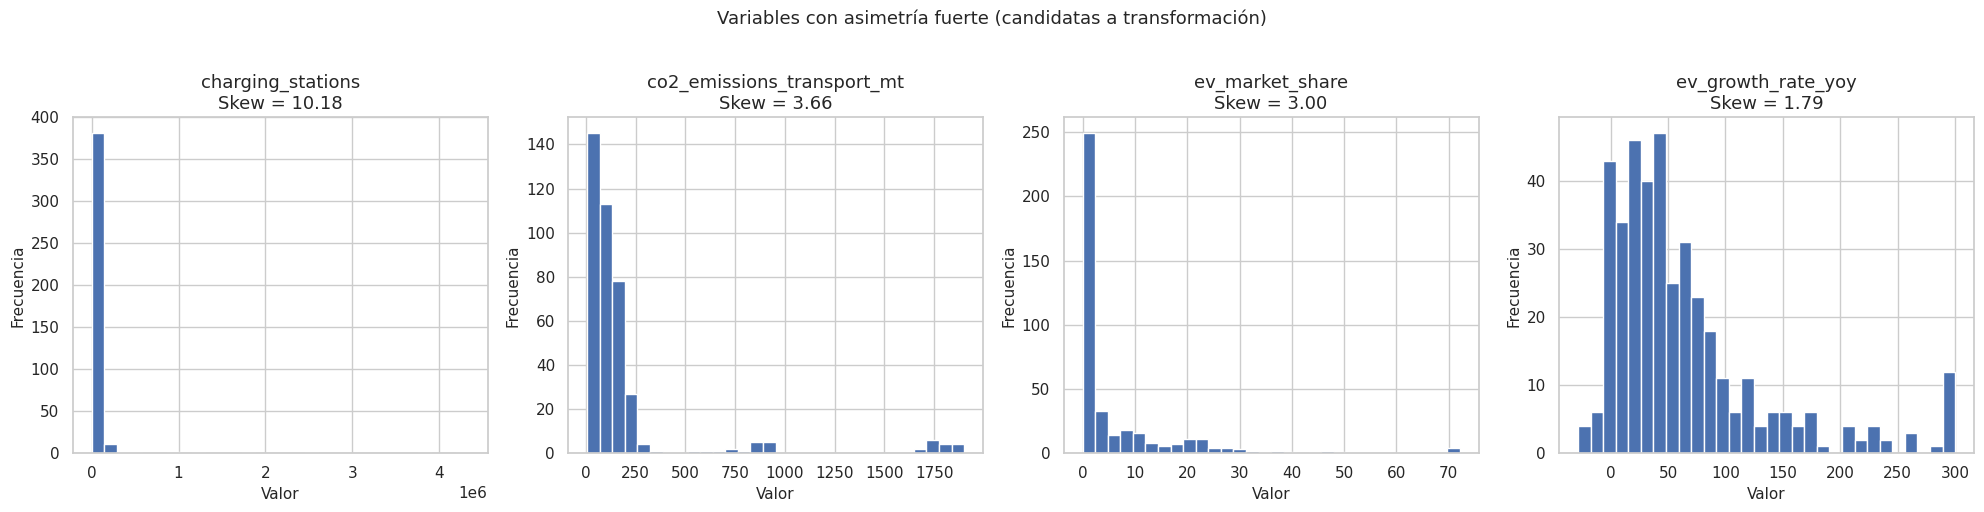

In [22]:
# Visualización de las distribuciones más asimétricas
vars_skew_altas = skew_df[skew_df['Skewness'].abs() >= 1]['Variable'].tolist()

n = len(vars_skew_altas)
fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
if n == 1: axes = [axes]

for ax, col in zip(axes, vars_skew_altas):
    ax.hist(df_pais[col], bins=30, edgecolor='white')
    ax.set_title(f"{col}\nSkew = {df_pais[col].skew():.2f}")
    ax.set_xlabel("Valor")
    ax.set_ylabel("Frecuencia")

plt.suptitle("Variables con asimetría fuerte (candidatas a transformación)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


### 3.2 Transformación logarítmica (log1p)

Se aplica la transformación `log(x + 1)` a las variables con asimetría fuerte (|skew| ≥ 1). El uso de `log1p` en lugar de `log` permite manejar valores cero sin error. Esta transformación acerca la distribución a la normalidad y reduce el impacto de valores extremos en modelos sensibles a escala.

**Variables seleccionadas para transformación:**
- `charging_stations` (skew ≈ 10.2): magnitudes que van de 0 a cientos de miles de estaciones
- `co2_emissions_transport_mt` (skew ≈ 3.7): economías grandes distorsionan la escala
- `ev_market_share` (skew ≈ 3.7): cola derecha pronunciada por países líderes

> `ev_sales` no se incluye en `df_pais` porque se agrega de forma diferente; se transformaría en `df` (segmento) si se modelara a ese nivel.


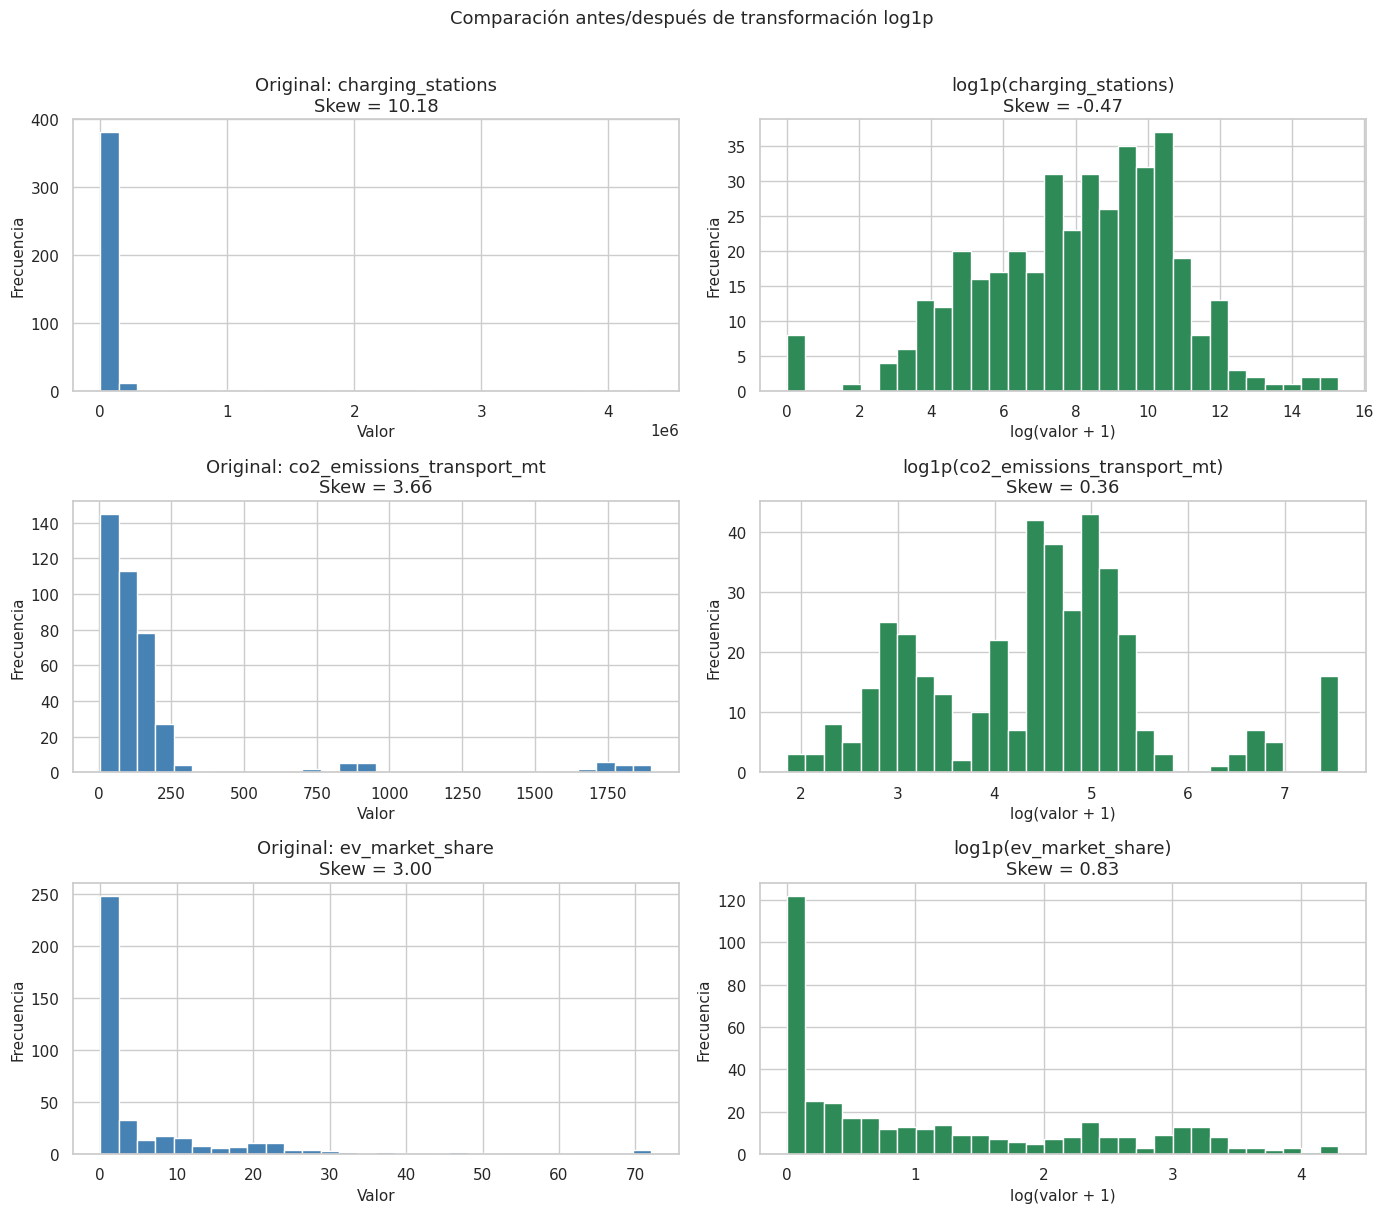

Columnas transformadas añadidas al dataset:
['log_charging_stations', 'log_co2_emissions_transport_mt', 'log_ev_market_share']


In [23]:
vars_log = ['charging_stations', 'co2_emissions_transport_mt', 'ev_market_share']

fig, axes = plt.subplots(len(vars_log), 2, figsize=(14, 4*len(vars_log)))

for i, col in enumerate(vars_log):
    original = df_pais[col]
    transformada = np.log1p(original)

    axes[i, 0].hist(original, bins=30, edgecolor='white', color='steelblue')
    axes[i, 0].set_title(f"Original: {col}\nSkew = {original.skew():.2f}")
    axes[i, 0].set_xlabel("Valor")
    axes[i, 0].set_ylabel("Frecuencia")

    axes[i, 1].hist(transformada, bins=30, edgecolor='white', color='seagreen')
    axes[i, 1].set_title(f"log1p({col})\nSkew = {transformada.skew():.2f}")
    axes[i, 1].set_xlabel("log(valor + 1)")
    axes[i, 1].set_ylabel("Frecuencia")

plt.suptitle("Comparación antes/después de transformación log1p", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Agregar columnas transformadas al dataset
for col in vars_log:
    df_pais[f"log_{col}"] = np.log1p(df_pais[col])

print("Columnas transformadas añadidas al dataset:")
print([c for c in df_pais.columns if c.startswith('log_')])


**Resultado de la transformación:**  
En los tres casos, la transformación `log1p` reduce significativamente la asimetría, acercando las distribuciones a formas más simétricas. Esto mejora el comportamiento de técnicas estadísticas que asumen normalidad (regresión lineal, PCA) y reduce el peso desproporcionado de los valores extremos. Las columnas originales se conservan para referencia e interpretabilidad.


### 3.3 Escalamiento — StandardScaler

El escalamiento estandariza cada variable para que tenga media 0 y desviación estándar 1 para llevarlas a la misma escala

Se aplica **después** de las transformaciones logarítmicas para no escalar distribuciones todavía asimétricas.

> **¿Por qué StandardScaler y no MinMaxScaler?** Dado que el dataset contiene outliers reales que se conservaron, MinMaxScaler concentraría la mayoría de los valores en un rango estrecho. StandardScaler es más robusto en presencia de colas largas.


In [24]:
# Variables finales para el dataset preprocesado
vars_escalar = [
    'log_ev_market_share', 'gdp_per_capita', 'ev_subsidy_usd',
    'fuel_price_usd_per_liter', 'electricity_price_usd_per_kwh',
    'log_charging_stations', 'fast_chargers_share', 'avg_ev_range_km',
    'emission_regulation_score', 'urban_population_percent',
    'log_co2_emissions_transport_mt', 'ev_growth_rate_yoy'
]

scaler = StandardScaler()
X_escalado = scaler.fit_transform(df_pais[vars_escalar])
df_scaled = pd.DataFrame(X_escalado, columns=vars_escalar)

print("Verificación del escalamiento (media y std por variable):")
print(df_scaled.describe().loc[['mean', 'std']].round(6).to_string())


Verificación del escalamiento (media y std por variable):
      log_ev_market_share  gdp_per_capita  ev_subsidy_usd  fuel_price_usd_per_liter  electricity_price_usd_per_kwh  log_charging_stations  fast_chargers_share  avg_ev_range_km  emission_regulation_score  urban_population_percent  log_co2_emissions_transport_mt  ev_growth_rate_yoy
mean            -0.000000       -0.000000       -0.000000                 -0.000000                      -0.000000              -0.000000            -0.000000        -0.000000                   0.000000                  0.000000                        0.000000           -0.000000
std              1.001252        1.001252        1.001252                  1.001252                       1.001252               1.001252             1.001252         1.001252                   1.001252                  1.001252                        1.001252            1.001252


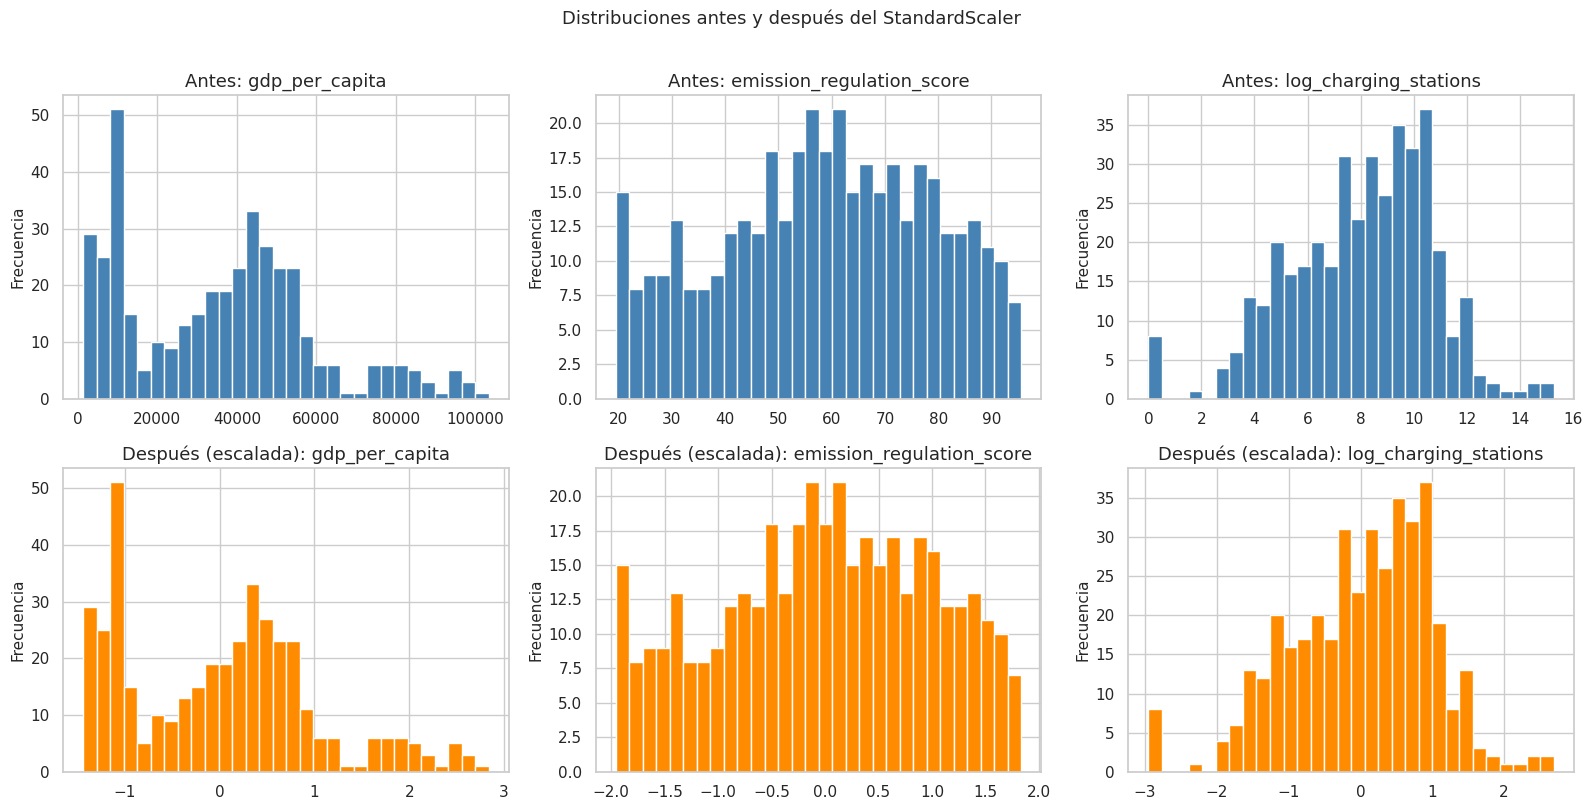

In [25]:
# Comparación visual: antes y después del escalamiento en 3 variables representativas
vars_vis = ['gdp_per_capita', 'emission_regulation_score', 'log_charging_stations']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for i, col in enumerate(vars_vis):
    # Original
    axes[0, i].hist(df_pais[col], bins=30, edgecolor='white', color='steelblue')
    axes[0, i].set_title(f"Antes: {col}")
    axes[0, i].set_ylabel("Frecuencia")

    # Escalada
    axes[1, i].hist(df_scaled[col], bins=30, edgecolor='white', color='darkorange')
    axes[1, i].set_title(f"Después (escalada): {col}")
    axes[1, i].set_ylabel("Frecuencia")

plt.suptitle("Distribuciones antes y después del StandardScaler", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


La media de cada variable escalada es 0 y su desviación estándar es 1, lo que permite comparar variables originalmente en unidades incompatibles (USD, km, porcentaje, etc.) en un espacio común.


### 3.4 Resumen del pipeline de preprocesamiento

El siguiente esquema resume las decisiones tomadas en el proceso de preparación de datos:

| Etapa | Decisión | Justificación |
|-------|----------|---------------|
| Verificación de nulos | No se imputa | Dataset sin valores faltantes |
| Outliers | Se conservan | Representan variación real entre países |
| Transformación log1p | `charging_stations`, `co2_emissions`, `ev_market_share` | Asimetría fuerte (|skew| ≥ 1) |
| Escalamiento | StandardScaler sobre 12 variables | Robustez ante outliers vs. MinMaxScaler |
| Segmentación | Se mantienen `df` (segmento) y `df_pais` (país-año) | Análisis en dos niveles de granularidad |


In [26]:
# Dataset final preprocesado — listo para modelado
df_final = df_pais[['country', 'region', 'year']].reset_index(drop=True)
df_final = pd.concat([df_final, df_scaled.reset_index(drop=True)], axis=1)
df_final['is_ev_dominant'] = df_pais['is_ev_dominant'].values

print("Dataset preprocesado final:")
print(f"  Filas: {df_final.shape[0]}, Columnas: {df_final.shape[1]}")
df_final.head()


Dataset preprocesado final:
  Filas: 400, Columnas: 16


,country,region,year,log_ev_market_share,gdp_per_capita,ev_subsidy_usd,fuel_price_usd_per_liter,electricity_price_usd_per_kwh,log_charging_stations,fast_chargers_share,avg_ev_range_km,emission_regulation_score,urban_population_percent,log_co2_emissions_transport_mt,ev_growth_rate_yoy,is_ev_dominant
0,Australia,Oceania,2010,-0.951810,0.683387,-1.175532,-0.694280,-0.258723,-2.954515,-1.436115,-1.163431,-1.412127,0.955454,0.051513,-0.923747,0.0
1,Australia,Oceania,2011,-0.940877,0.718131,-1.175532,-0.694280,-0.082101,-1.231731,-1.286911,-1.089626,-1.392211,0.962187,0.047784,0.820418,0.0
2,Australia,Oceania,2012,-0.935464,0.771210,-1.175532,-0.757587,0.094520,-1.012272,-1.107866,-1.073225,-1.352379,0.935256,0.058921,0.102768,0.0
3,Australia,Oceania,2013,-0.911532,0.834293,-1.175532,-0.851171,0.283758,-0.838882,-0.938768,-1.007621,-1.272716,1.009317,0.063518,0.543932,0.0
4,Australia,Oceania,2014,-0.890823,0.807419,-1.175532,-0.961270,0.472996,-0.732907,-0.789564,-0.942016,-1.272716,1.002584,0.084344,-0.085197,0.0


---
## 📝 Conclusiones del proceso analítico

### Hallazgos principales

1. **Variables más asociadas a la adopción:** La regulación ambiental (`emission_regulation_score`), el precio del combustible (`fuel_price_usd_per_liter`) y la autonomía promedio del EV (`avg_ev_range_km`) son los factores con mayor correlación lineal con `ev_market_share`. Esto sugiere que la adopción responde más a políticas públicas y al costo relativo de movilidad que a subsidios directos.

2. **El subsidio no explica la adopción de forma simple:** La correlación negativa de `ev_subsidy_usd` con `ev_market_share` apunta a un efecto de selección inversa: los países con menor adopción otorgan más subsidios para incentivar el mercado. Este hallazgo es relevante para el diseño de política pública.

3. **Heterogeneidad regional estructural:** Europa y APAC muestran patrones de adopción sistemáticamente superiores al resto de regiones, lo que indica la presencia de factores culturales, institucionales o de política industrial que el dataset no captura completamente.

4. **Outliers genuinos, no errores:** Los valores extremos pertenecen a países líderes o economías de gran escala. Eliminarlos sesgaría el análisis al excluir precisamente los casos más informativos.

5. **Necesidad de transformación logarítmica:** Variables como `charging_stations` y `co2_emissions_transport_mt` presentan distribuciones extremadamente asimétricas que requieren transformación antes de aplicar modelos paramétricos.

### Limitaciones identificadas

- El dataset tiene granularidad país-año, lo que impide analizar decisiones individuales del consumidor.
- Algunas variables pueden estar altamente correlacionadas entre sí (multicolinealidad), lo que complicará la interpretación causal en modelos de regresión.
- Variables no observadas (cultura, percepción del consumidor, disponibilidad de modelos específicos) podrían ser determinantes importantes no incluidos en el dataset.


---
## 📚 Referencias

- Mishra, A. (2024). *Will EVs Replace Petrol Cars?* [Dataset]. Kaggle. https://www.kaggle.com/datasets/aryanmdev/will-evs-replace-petrol-cars/

- McKinney, W. (2022). *Python for Data Analysis* (3.ª ed.). O'Reilly Media.

- Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830. https://scikit-learn.org/

- Waskom, M. L. (2021). Seaborn: Statistical Data Visualization. *Journal of Open Source Software*, 6(60), 3021. https://doi.org/10.21105/joss.03021

- Liu, F. T., Ting, K. M., & Zhou, Z.-H. (2008). Isolation Forest. *2008 Eighth IEEE International Conference on Data Mining*, 413–422.

- Breunig, M. M., Kriegel, H.-P., Ng, R. T., & Sander, J. (2000). LOF: Identifying Density-Based Local Outliers. *Proceedings of the 2000 ACM SIGMOD International Conference on Management of Data*, 93–104.
